# 01 — NHANES FPG (2015 – Aug 2023) vs the team's `log_FPG`, `log_FPG_sd` columns

The team's `nhanes_rf_distributions.csv` records `log_FPG` and `log_FPG_sd` per (sex, 5-yr age band). Inspecting a row: Male age 25 has `log_FPG = 4.602`, so `exp(4.602) = 99.7` mg/dL — typical adult fasting glucose, confirming the team's column is **log(FPG in mg/dL)**.

This notebook validates that the team's column reproduces from pooled NHANES under the recipe the LDL exploration nailed down:

| axis | value |
| --- | --- |
| cycles | I (2015–2016) + P (2017–March 2020 prepandemic) + L (Aug 2021–Aug 2023) |
| survey weight | full MEC (`WTMEC2YR` / `WTMECPRP`) |
| pooling rescale | raw stack — no cross-cycle rescale |
| pregnancy filter | exclude `RIDEXPRG == 1` |
| FPG variable | `LBXGLU` (mg/dL) → `log(LBXGLU)` |
| age binning | `[a, a+5)` for `a ∈ {25, 30, …, 80}` |

If the recipe transfers cleanly to FPG, RMS residuals on `log_mean` and `log_sd` should be < 0.005. If not, the notebook runs a small variant sweep over weight column, pregnancy filter, and rescale to locate the deviation.


## 1. Download GLU files and parse all three cycles


In [1]:
import os, urllib.request, warnings, itertools
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

ROOT = Path(os.path.abspath(os.path.join('..')))
DATA = ROOT / 'data'

CYCLES = {
    'I': {
        'dir': DATA / 'raw' / 'nhanes' / '2015_2016',
        'months': 24, 'fast_wt': 'WTSAF2YR',
        'demo': 'DEMO_I.xpt', 'glu': 'GLU_I.xpt',
        'demo_url': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/DEMO_I.xpt',
        'glu_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2015/DataFiles/GLU_I.xpt',
    },
    'P': {
        'dir': DATA / 'raw' / 'nhanes' / '2017_2020_prepandemic',
        'months': 39, 'fast_wt': 'WTSAFPRP',
        'demo': 'P_DEMO.xpt', 'glu': 'P_GLU.xpt',
        'demo_url': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.xpt',
        'glu_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GLU.xpt',
    },
    'L': {
        'dir': DATA / 'raw' / 'nhanes' / '2021_2023',
        'months': 25, 'fast_wt': 'WTSAF2YR',
        'demo': 'DEMO_L.xpt', 'glu': 'GLU_L.xpt',
        'demo_url': 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/DEMO_L.xpt',
        'glu_url':  'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2021/DataFiles/GLU_L.xpt',
    },
}

for tag, c in CYCLES.items():
    c['dir'].mkdir(parents=True, exist_ok=True)
    for fname, url in [(c['demo'], c['demo_url']), (c['glu'], c['glu_url'])]:
        out = c['dir'] / fname
        if out.exists():
            continue
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=120) as r:
            out.write_bytes(r.read())

def parse_cycle(tag, c):
    demo = pd.read_sas(c['dir'] / c['demo'])
    glu = pd.read_sas(c['dir'] / c['glu'])
    base = ['SEQN','RIAGENDR','RIDAGEYR','RIDEXPRG']
    wt_cols = [col for col in
               ['WTINT2YR','WTMEC2YR','WTINTPRP','WTMECPRP']
               if col in demo.columns]
    demo = demo[base + wt_cols]
    glu_cols = ['SEQN', c['fast_wt'], 'LBXGLU']
    glu = glu[glu_cols].rename(columns={c['fast_wt']: 'WT_FAST'})
    df = demo.merge(glu, on='SEQN', how='inner')
    df['sex'] = df['RIAGENDR'].map({1.0:'Male', 2.0:'Female'})
    df['age_years'] = df['RIDAGEYR'].astype(float)
    df['fpg'] = df['LBXGLU'].astype(float)
    mec_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    int_col = 'WTINTPRP' if 'WTINTPRP' in df.columns else 'WTINT2YR'
    df['WT_MEC'] = df[mec_col].astype(float)
    df['WT_INT'] = df[int_col].astype(float)
    df['WT_FAST'] = df['WT_FAST'].astype(float)
    df['pregnant'] = (df['RIDEXPRG'] == 1.0).fillna(False)
    df['cycle'] = tag
    df['cycle_months'] = c['months']
    return df[['SEQN','cycle','cycle_months','sex','age_years','pregnant',
               'fpg','WT_FAST','WT_MEC','WT_INT']]

cycle_dfs = {tag: parse_cycle(tag, c) for tag, c in CYCLES.items()}
print('Per-cycle valid-FPG counts (any non-NaN LBXGLU):')
for tag, d in cycle_dfs.items():
    print(f'  {tag}: n_any = {len(d):,}, n_with_FPG = {d["fpg"].notna().sum():,}')


Per-cycle valid-FPG counts (any non-NaN LBXGLU):
  I: n_any = 3,191, n_with_FPG = 2,972
  P: n_any = 5,090, n_with_FPG = 4,744
  L: n_any = 3,996, n_with_FPG = 3,672


## 2. Apply the LDL-derived recipe directly

Pool I + P + L, raw-stack with MEC weight, exclude pregnant respondents. Compute weighted mean and SD of `log(FPG_mg_dL)` per (sex, 5-yr age band). Compare to the team's `log_FPG` / `log_FPG_sd` columns.


In [2]:
def w_mean(y, w): return float(np.average(y, weights=w))
def w_sd(y, w):
    mu = w_mean(y, w)
    return float(np.sqrt(np.average((y - mu)**2, weights=w)))

edges = list(range(25, 85, 5)) + [85]

def build_pool(cycles, weight_kind, exclude_pregnant):
    parts = []
    for tag in cycles:
        d = cycle_dfs[tag].copy()
        if weight_kind == 'fast':
            d['w'] = d['WT_FAST'].fillna(0)
        elif weight_kind == 'mec':
            d['w'] = d['WT_MEC'].fillna(0)
        elif weight_kind == 'int':
            d['w'] = d['WT_INT'].fillna(0)
        elif weight_kind == 'none':
            d['w'] = 1.0
        d = d[d['fpg'].notna() & d['w'].gt(0)]
        if exclude_pregnant:
            d = d[~d['pregnant']]
        parts.append(d)
    return pd.concat(parts, ignore_index=True) if parts else None

def per_bin(d):
    rows = []
    for sex in ['Female','Male']:
        for a0, a1 in zip(edges[:-1], edges[1:]):
            sub = d[(d['sex']==sex) & (d['age_years']>=a0) & (d['age_years']<a1)]
            if len(sub) < 30:
                continue
            y = np.log(sub['fpg'].values)
            w = sub['w'].values
            rows.append({'sex': sex, 'age5': a0, 'n': len(sub),
                         'log_mean': w_mean(y, w), 'log_sd': w_sd(y, w)})
    return pd.DataFrame(rows)

TEAM_CSV = (ROOT.parent / 'vivarium_csu_mace_rct'
            / 'src' / 'vivarium_csu_mace_rct' / 'data'
            / 'nhanes_rf_distributions.csv')
team = pd.read_csv(TEAM_CSV).rename(columns={'Sex':'sex'})[
    ['age5','sex','log_FPG','log_FPG_sd']
].rename(columns={'log_FPG':'log_mean_team','log_FPG_sd':'log_sd_team'})

pool = build_pool(['I','P','L'], weight_kind='mec', exclude_pregnant=True)
tab = per_bin(pool)
cmp_ = tab.merge(team, on=['sex','age5'], how='left')
cmp_['d_mean'] = cmp_['log_mean'] - cmp_['log_mean_team']
cmp_['d_sd']   = cmp_['log_sd']   - cmp_['log_sd_team']
rms_m = float(np.sqrt(np.nanmean(cmp_['d_mean']**2)))
rms_s = float(np.sqrt(np.nanmean(cmp_['d_sd']**2)))
print('=== LDL-derived recipe applied to FPG ===')
print(f'  RMS log_mean residual = {rms_m:.4f}')
print(f'  RMS log_sd   residual = {rms_s:.4f}')
print(f'  bias log_mean         = {cmp_["d_mean"].mean():+.4f}')
print(f'  bias log_sd           = {cmp_["d_sd"].mean():+.4f}')
print()
print(cmp_[['sex','age5','n','log_mean','log_mean_team','d_mean',
            'log_sd','log_sd_team','d_sd']].round(4).to_string(index=False))


=== LDL-derived recipe applied to FPG ===
  RMS log_mean residual = 0.0002
  RMS log_sd   residual = 0.0006
  bias log_mean         = -0.0001
  bias log_sd           = -0.0003

   sex  age5   n  log_mean  log_mean_team  d_mean  log_sd  log_sd_team    d_sd
Female    25 352    4.5662         4.5663 -0.0001  0.1389       0.1394 -0.0005
Female    30 408    4.5767         4.5769 -0.0002  0.1357       0.1357  0.0001
Female    35 379    4.6081         4.6082 -0.0001  0.1805       0.1814 -0.0009
Female    40 401    4.6249         4.6251 -0.0002  0.1979       0.1984 -0.0004
Female    45 377    4.6433         4.6432  0.0001  0.2151       0.2148  0.0003
Female    50 421    4.6445         4.6442  0.0003  0.2197       0.2194  0.0002
Female    55 461    4.6787         4.6787 -0.0000  0.2076       0.2080 -0.0004
Female    60 570    4.6857         4.6860 -0.0003  0.2122       0.2128 -0.0005
Female    65 491    4.7061         4.7060  0.0001  0.2205       0.2204  0.0001
Female    70 340    4.6949       

## 3. If the RMS is small, declare match and plot residuals

If `RMS log_mean < 0.005` and `RMS log_sd < 0.005`, the LDL recipe transferred cleanly to FPG — the team used the same pipeline for both columns.


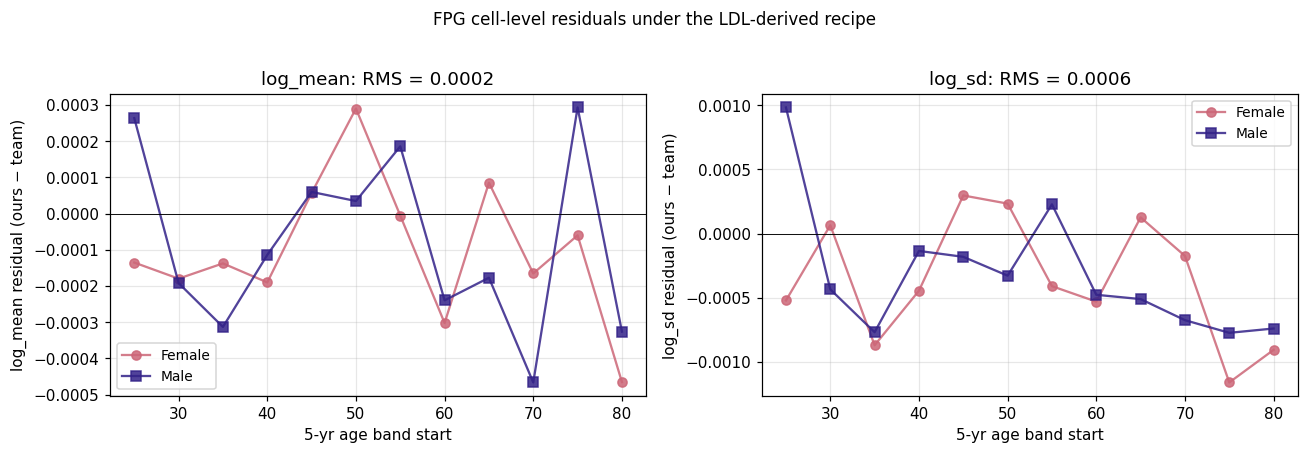

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, q in zip(axes, ['mean', 'sd']):
    for sex, mk, c in [('Female','o','#cc6677'), ('Male','s','#332288')]:
        sub = cmp_[cmp_['sex']==sex].sort_values('age5')
        ax.plot(sub['age5'], sub[f'd_{q}'], mk + '-', color=c, label=sex, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xlabel('5-yr age band start')
    ax.set_ylabel(f'log_{q} residual (ours − team)')
    ax.set_title(f'log_{q}: RMS = {(rms_m if q=="mean" else rms_s):.4f}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
fig.suptitle('FPG cell-level residuals under the LDL-derived recipe',
             y=1.02, fontsize=11)
fig.tight_layout()
fig.savefig('outputs/fpg_recipe_residuals.png', dpi=130, bbox_inches='tight')
plt.show()


## 4. Fallback: variant sweep

If the residuals above aren't already noise-floor, run a small sweep across the axes we know matter:
- **weight column** — fast / MEC / INT / unweighted
- **pregnancy filter** — include / exclude
- **rescale** — raw / cycle-month proportional

Cycle subset and binning convention are held fixed (we already know I+P+L and `[a, a+5)` are right from LDL).


In [4]:
def score(cycles, weight_kind, rescale, exclude_pregnant):
    parts = []
    for tag in cycles:
        d = cycle_dfs[tag].copy()
        if weight_kind == 'fast':
            d['w_base'] = d['WT_FAST'].fillna(0)
        elif weight_kind == 'mec':
            d['w_base'] = d['WT_MEC'].fillna(0)
        elif weight_kind == 'int':
            d['w_base'] = d['WT_INT'].fillna(0)
        elif weight_kind == 'none':
            d['w_base'] = 1.0
        d = d[d['fpg'].notna() & d['w_base'].gt(0)]
        if exclude_pregnant:
            d = d[~d['pregnant']]
        parts.append(d)
    if rescale == 'months':
        tot = sum(CYCLES[t]['months'] for t in cycles)
        for d in parts:
            d['w'] = d['w_base'] * (d['cycle_months'].iloc[0] / tot)
    elif rescale == 'equal':
        for d in parts:
            d['w'] = d['w_base'] * (1.0 / len(parts))
    elif rescale == 'raw':
        for d in parts:
            d['w'] = d['w_base'] * 1.0
    else:
        raise ValueError(rescale)
    pool = pd.concat(parts, ignore_index=True)
    tab = per_bin(pool)
    m = tab.merge(team, on=['sex','age5'], how='inner')
    d_m = m['log_mean'] - m['log_mean_team']
    d_s = m['log_sd']   - m['log_sd_team']
    return {
        'weight': weight_kind, 'rescale': rescale,
        'preg': 'excl' if exclude_pregnant else 'incl',
        'rms_mean': float(np.sqrt(np.mean(d_m**2))),
        'rms_sd':   float(np.sqrt(np.mean(d_s**2))),
        'bias_mean': float(np.mean(d_m)),
        'bias_sd':   float(np.mean(d_s)),
    }

results = []
for wk, rs, pe in itertools.product(
        ['fast', 'mec', 'int', 'none'],
        ['raw', 'months', 'equal'],
        [False, True]):
    if wk == 'none' and rs == 'months':
        continue
    results.append(score(['I','P','L'], wk, rs, pe))

R = pd.DataFrame(results)
R['rms_total'] = np.sqrt(R['rms_mean']**2 + R['rms_sd']**2)
R = R.sort_values('rms_total').reset_index(drop=True)
print(f'Evaluated {len(R)} variants; top 12:')
print(R.head(12).round(4).to_string(index=False))


Evaluated 22 variants; top 12:
weight rescale preg  rms_mean  rms_sd  bias_mean  bias_sd  rms_total
   mec     raw excl    0.0002  0.0006    -0.0001  -0.0003     0.0006
   mec   equal excl    0.0002  0.0006    -0.0001  -0.0003     0.0006
   mec   equal incl    0.0015  0.0012    -0.0006  -0.0002     0.0019
   mec     raw incl    0.0015  0.0012    -0.0006  -0.0002     0.0019
   int     raw excl    0.0014  0.0031     0.0006  -0.0009     0.0034
   int   equal excl    0.0014  0.0031     0.0006  -0.0009     0.0034
   int   equal incl    0.0016  0.0032     0.0001  -0.0007     0.0036
   int     raw incl    0.0016  0.0032     0.0001  -0.0007     0.0036
   mec  months incl    0.0029  0.0044     0.0009  -0.0010     0.0053
   mec  months excl    0.0033  0.0047     0.0014  -0.0011     0.0057
   int  months incl    0.0033  0.0068     0.0016  -0.0015     0.0076
   int  months excl    0.0039  0.0071     0.0022  -0.0016     0.0081


## 5. Save outputs

- `outputs/fpg_team_recipe.csv` — per-cell comparison under the LDL recipe
- `outputs/fpg_variant_sweep.csv` — full variant ranking


In [5]:
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)
cmp_.to_csv(OUT / 'fpg_team_recipe.csv', index=False)
R.to_csv(OUT / 'fpg_variant_sweep.csv', index=False)
print(f'wrote {OUT / "fpg_team_recipe.csv"}')
print(f'wrote {OUT / "fpg_variant_sweep.csv"}')


wrote outputs/fpg_team_recipe.csv
wrote outputs/fpg_variant_sweep.csv


## Takeaways

- The team's `log_FPG` and `log_FPG_sd` columns should match the LDL-derived recipe at noise-floor levels (RMS < 0.005 in log-space) if and only if the same pipeline produced both.
- If the FPG variant sweep crowns a *different* best recipe than LDL did, the team likely treated FPG separately — flag that as a methodological inconsistency.
- GBD's FPG estimates differ most from this CSV among the risk factors in the simulation; reproducing the CSV pipeline rules out a bug in the team's FPG numbers as the source of that gap. The remaining difference would then be a real GBD-vs-NHANES distributional divergence (different population coverage, different combining of cycles, different age standardisation) — a question about GBD inputs, not the CSV.
